#Project Title

###Spotify Churn Analysis

#Domain
Retail / E-commerce


#Objective

1. To identify key patterns and trends in user listening behavior and subscription activity using exploratory data analysis (EDA)
2. To clean, preprocess, and transform the Spotify user dataset to ensure accurate and reliable analysis
3. To analyze factors influencing customer churn and understand differences between active and churned users
4. To create meaningful visualizations that effectively illustrate user behavior, engagement levels, and churn patterns
5. To provide actionable insights and data-driven recommendations to improve user retention and reduce churn

#Outcome
The project identifies key factors driving customer churn by analyzing user behavior and engagement patterns. It provides clear insights to support data-driven decisions for improving customer retention.

#Dataset Information

Source: Kaggle – Spotify Dataset for Churn Analysis 2025

Year / Timeline: 2025

Dataset Description:

This dataset contains information about Spotify users, including their demographics, listening behavior, and subscription details. Each row represents an individual user and is used to analyze and predict customer churn.

Rows: Each row represents a unique Spotify user.

Columns (Features):

user_id → Unique identifier for each user

gender → User gender (Male/Female/Other)

age → User age

country → User location

subscription_type → Type of Spotify subscription (Free, Premium, Family, Student)

listening_time → Minutes spent listening per day

songs_played_per_day → Number of songs played daily

skip_rate → Percentage of songs skipped

device_type → Device used (Mobile, Desktop, Web)

ads_listened_per_week → Number of ads heard per week

offline_listening → Offline mode usage

is_churned → Target variable (0 = Active, 1 = Churned)

Dataset Type: Mixed (numeric + categorical)

#Type of Analysis
1. Data Cleaning & Preparation – Handling missing values and preparing the dataset for analysis
2. Exploratory Data Analysis (EDA) – Understanding user behavior and key patterns
3. Churn Analysis – Identifying differences between active and churned users
4. Data Visualization – Creating clear charts to represent insights
5. Insights & Recommendations – Providing actionable suggestions to improve customer retention

# Stages for DA Project

## Stage 1 – Problem Definition and Dataset Selection
Business Problem:

Spotify faces customer churn where users stop using the platform or cancel subscriptions. Identifying the key factors influencing churn is essential to improve user retention.

Expected Outcome:

To analyze user behavior and identify patterns that lead to churn, and provide data-driven insights and recommendations to help reduce churn and improve customer retention.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('spotify_churn_dataset_uncleaned.csv') #Loading dataset into pandas dataframe
df

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,17,18,0.20,Desktop,31.0,0,1
1,2,Other,33,DE,Family,148,64,0.34,Web,0.0,1,0
2,3,Male,38,AU,Premium,7,29,0.04,Mobile,0.0,1,1
3,4,Female,22,CA,Student,26,2,0.31,Mobile,0.0,1,1
4,5,Other,29,US,Family,265,59,0.36,Mobile,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
7995,7996,Other,44,DE,Student,252,37,0.30,Mobile,0.0,1,0
7996,7997,Male,34,AU,Premium,65,67,0.59,Mobile,0.0,1,0
7997,7998,Female,17,US,Free,83,65,0.33,Desktop,5.0,0,0
7998,7999,Female,34,IN,Student,251,96,0.27,Desktop,0.0,1,0


In [7]:
df.describe()

,user_id,age,listening_time,songs_played_per_day,skip_rate,ads_listened_per_week,offline_listening,is_churned
count,8000.00000,8000.000000,8000.000000,8000.000000,7976.000000,7946.000000,8000.000000,8000.000000
mean,4000.50000,37.662125,149.793500,48.674500,0.301031,6.991065,0.747750,0.218250
std,2309.54541,12.740359,90.867996,28.518156,0.173071,13.652075,0.434331,0.413084
min,1.00000,16.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2000.75000,26.000000,68.000000,24.000000,0.150000,0.000000,0.000000,0.000000
50%,4000.50000,38.000000,138.000000,48.000000,0.300000,0.000000,1.000000,0.000000
75%,6000.25000,49.000000,233.000000,72.000000,0.450000,5.000000,1.000000,0.000000
max,8000.00000,59.000000,323.000000,104.000000,0.600000,49.000000,1.000000,1.000000


In [8]:
df.head()

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,17,18,0.20,Desktop,31.0,0,1
1,2,Other,33,DE,Family,148,64,0.34,Web,0.0,1,0
2,3,Male,38,AU,Premium,7,29,0.04,Mobile,0.0,1,1
3,4,Female,22,CA,Student,26,2,0.31,Mobile,0.0,1,1
4,5,Other,29,US,Family,265,59,0.36,Mobile,0.0,1,0


In [9]:
df.tail()

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
7995,7996,Other,44,DE,Student,252,37,0.30,Mobile,0.0,1,0
7996,7997,Male,34,AU,Premium,65,67,0.59,Mobile,0.0,1,0
7997,7998,Female,17,US,Free,83,65,0.33,Desktop,5.0,0,0
7998,7999,Female,34,IN,Student,251,96,0.27,Desktop,0.0,1,0
7999,8000,Other,45,AU,Free,226,71,0.46,Desktop,6.0,0,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                8000 non-null   int64  
 1   gender                 8000 non-null   object 
 2   age                    8000 non-null   int64  
 3   country                8000 non-null   object 
 4   subscription_type      8000 non-null   object 
 5   listening_time         8000 non-null   int64  
 6   songs_played_per_day   8000 non-null   int64  
 7   skip_rate              7976 non-null   float64
 8   device_type            7986 non-null   object 
 9   ads_listened_per_week  7946 non-null   float64
 10  offline_listening      8000 non-null   int64  
 11  is_churned             8000 non-null   int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 750.1+ KB


In [11]:
df.isnull().sum()

,0
user_id,0
gender,0
age,0
country,0
subscription_type,0
listening_time,0
songs_played_per_day,0
skip_rate,24
device_type,14
ads_listened_per_week,54


In [12]:
df.shape

(8000, 12)

In [13]:
df.size

96000

In [14]:
df.duplicated().sum()

np.int64(0)

##Stage 2 – Data Cleaning and Pre-processing

In [15]:
df.songs_played_per_day.unique()

array([ 18,  64,  29,   2,  59,  36,  45,  70,  21,  95,  61,  35,  11,
        20,  13,   8,  32,  37,  62,   5,  97, 100,  23,  54,  57,  14,
        10,  46,  77,  38,  74, 101,  44,  16,  30,  92,  72,   3,  78,
        99,  68,  51,  60,  27,  33,  53,  43,  26,  42,  28,   9,  86,
         6,  76,  31,  88,  71,   4,  39,  81,  85,   7,   1,  15,  63,
        79,  24,  49,  73,  48,  84,  69,  52,  25,  19,  65,  67,  80,
        58,  40,  83,  55,  22,  34, 103,  12,  47,  17,  90,  94,  93,
       102,  98,  56,  87,  50,  91,  75,  66,  89,  96,  41,  82, 104,
         0])

In [16]:
df['songs_played_per_day'] = df['songs_played_per_day'].fillna(df['songs_played_per_day'].mean().round()).astype(int)

In [17]:
df.songs_played_per_day.unique()

array([ 18,  64,  29,   2,  59,  36,  45,  70,  21,  95,  61,  35,  11,
        20,  13,   8,  32,  37,  62,   5,  97, 100,  23,  54,  57,  14,
        10,  46,  77,  38,  74, 101,  44,  16,  30,  92,  72,   3,  78,
        99,  68,  51,  60,  27,  33,  53,  43,  26,  42,  28,   9,  86,
         6,  76,  31,  88,  71,   4,  39,  81,  85,   7,   1,  15,  63,
        79,  24,  49,  73,  48,  84,  69,  52,  25,  19,  65,  67,  80,
        58,  40,  83,  55,  22,  34, 103,  12,  47,  17,  90,  94,  93,
       102,  98,  56,  87,  50,  91,  75,  66,  89,  96,  41,  82, 104,
         0])

In [18]:
df.skip_rate.unique()

array([0.2 , 0.34, 0.04, 0.31, 0.36, 0.46, 0.38, 0.11, 0.29, 0.56, 0.6 ,
       0.44, 0.26, 0.23, 0.41, 0.35, 0.45, 0.1 , 0.42, 0.59, 0.53, 0.33,
       0.3 , 0.22, 0.39, 0.17, 0.43, 0.18, 0.06, 0.5 , 0.54, 0.51, 0.4 ,
       0.48, 0.58, 0.08, 0.  , 0.32, 0.49, 0.14, 0.21, 0.05, 0.19, 0.47,
       0.24, 0.03, 0.37, 0.15, 0.25, 0.07, 0.02, 0.12, 0.27, 0.13, 0.16,
       0.52, 0.09,  nan, 0.28, 0.01, 0.55, 0.57])

In [19]:
df['skip_rate']=df['skip_rate'].fillna(0)

In [20]:
df.isnull().sum()

,0
user_id,0
gender,0
age,0
country,0
subscription_type,0
listening_time,0
songs_played_per_day,0
skip_rate,0
device_type,14
ads_listened_per_week,54


In [21]:
df.device_type.unique()

array(['Desktop', 'Web', 'Mobile', nan], dtype=object)

In [22]:
df['device_type'] = df['device_type'].fillna(df['device_type'].mode()[0])

In [23]:
df.device_type.unique()

array(['Desktop', 'Web', 'Mobile'], dtype=object)

In [24]:
df.device_type

,device_type
0,Desktop
1,Web
2,Mobile
3,Mobile
4,Mobile
...,...
7995,Mobile
7996,Mobile
7997,Desktop
7998,Desktop


In [25]:
df.isnull().sum()

,0
user_id,0
gender,0
age,0
country,0
subscription_type,0
listening_time,0
songs_played_per_day,0
skip_rate,0
device_type,0
ads_listened_per_week,54


In [26]:
df.ads_listened_per_week.unique()

array([31.,  0., 13.,  5., 44., 37., 39., 23., 35.,  7., 28., 22., 43.,
       15., 12., 19., 38., 14., 18., 10., 32., 29., 20., nan, 16.,  6.,
       36., 27., 49., 40., 47.,  9., 45., 42., 48., 26.,  8., 24., 30.,
       25., 41., 21., 34., 17., 46., 33., 11.])

In [27]:
df.ads_listened_per_week.value_counts(dropna=False)

,count
ads_listened_per_week,
0.0,5928
47.0,58
44.0,57
16.0,55
NaN,54
35.0,53
39.0,53
41.0,53
46.0,51


In [28]:
df['ads_listened_per_week']=df['ads_listened_per_week'].fillna(0)

In [29]:
df.ads_listened_per_week.unique()

array([31.,  0., 13.,  5., 44., 37., 39., 23., 35.,  7., 28., 22., 43.,
       15., 12., 19., 38., 14., 18., 10., 32., 29., 20., 16.,  6., 36.,
       27., 49., 40., 47.,  9., 45., 42., 48., 26.,  8., 24., 30., 25.,
       41., 21., 34., 17., 46., 33., 11.])

In [30]:
df.ads_listened_per_week.value_counts(dropna=False)

,count
ads_listened_per_week,
0.0,5982
47.0,58
44.0,57
16.0,55
35.0,53
39.0,53
41.0,53
46.0,51
45.0,50


In [31]:
df.isnull().sum()

,0
user_id,0
gender,0
age,0
country,0
subscription_type,0
listening_time,0
songs_played_per_day,0
skip_rate,0
device_type,0
ads_listened_per_week,0


In [32]:
df["ads_listened_per_week"].describe()

,ads_listened_per_week
count,8000.000000
mean,6.943875
std,13.617953
min,0.000000
25%,0.000000
50%,0.000000
75%,5.000000
max,49.000000


In [33]:
df.groupby("is_churned")["ads_listened_per_week"].mean()

,ads_listened_per_week
is_churned,
0,6.970899
1,6.847079


Although initial visualization suggested differences in ad exposure, statistical comparison showed that average ad consumption is nearly identical across churned and non-churned users. This indicates that ad exposure is not a primary factor influencing churn.

### Checking Skewness

In [34]:
from scipy.stats import skew

# Select only numeric columns for skewness calculation, excluding binary and identifier columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols_for_skew = [col for col in numeric_cols if col not in ['user_id', 'offline_listening', 'is_churned']]

# Calculate skewness for each relevant numeric column
skewed_features = df[numeric_cols_for_skew].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)

print("Skewness of numerical features:")
print(skewed_features)

Skewness of numerical features:
ads_listened_per_week    1.799407
listening_time           0.163768
songs_played_per_day     0.085818
skip_rate                0.005879
age                     -0.027430
dtype: float64


In [35]:
df.ads_listened_per_week.unique()

array([31.,  0., 13.,  5., 44., 37., 39., 23., 35.,  7., 28., 22., 43.,
       15., 12., 19., 38., 14., 18., 10., 32., 29., 20., 16.,  6., 36.,
       27., 49., 40., 47.,  9., 45., 42., 48., 26.,  8., 24., 30., 25.,
       41., 21., 34., 17., 46., 33., 11.])

In [36]:
df.dtypes

,0
user_id,int64
gender,object
age,int64
country,object
subscription_type,object
listening_time,int64
songs_played_per_day,int64
skip_rate,float64
device_type,object
ads_listened_per_week,float64


## Feature Engineering

To enhance our analysis, we will create new features that combine or transform existing columns. These derived features can often provide more direct insights into user behavior and potential churn drivers.

In [37]:
# 1. Create 'engagement_score'
# This score combines listening time and songs played, assuming both contribute to engagement.
# We can normalize them first to ensure fair weighting, or simply sum them if their scales are comparable.
df['engagement_score'] = (df['listening_time'] * df['songs_played_per_day']) / (1 + df['skip_rate'])
# Scale down values
df['engagement_score'] = df['engagement_score'] / 100

# Round values
df['engagement_score'] = df['engagement_score'].round(0)

# 2. Create 'ad_exposure_per_hour'
# This feature calculates the number of ads listened per hour of listening time.
# Add a small constant to 'listening_time' to avoid division by zero for users with 0 listening time.
df['ad_exposure_per_hour'] = df['ads_listened_per_week'] / (df['listening_time'] / 60 + 1e-6) # Divide by 60 to convert minutes to hours
df['ad_exposure_per_hour'] = df['ad_exposure_per_hour'].round().astype(int)

# 3. Create 'age_group'
# Categorize users into age groups for easier demographic analysis.
bins = [0, 18, 25, 35, 50, df['age'].max()+1]
labels = ['Teenager', 'Young Adult', 'Adult', 'Middle-Aged', 'Senior']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

display(df.head())

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned,engagement_score,ad_exposure_per_hour,age_group
0,1,Female,54,CA,Free,17,18,0.20,Desktop,31.0,0,1,3.0,109,Senior
1,2,Other,33,DE,Family,148,64,0.34,Web,0.0,1,0,71.0,0,Adult
2,3,Male,38,AU,Premium,7,29,0.04,Mobile,0.0,1,1,2.0,0,Middle-Aged
3,4,Female,22,CA,Student,26,2,0.31,Mobile,0.0,1,1,0.0,0,Young Adult
4,5,Other,29,US,Family,265,59,0.36,Mobile,0.0,1,0,115.0,0,Adult


##Stage 3 – EDA and Visualizations

In [38]:
#Univariate Analysis

### Distribution of Categorical Features (Countplots)

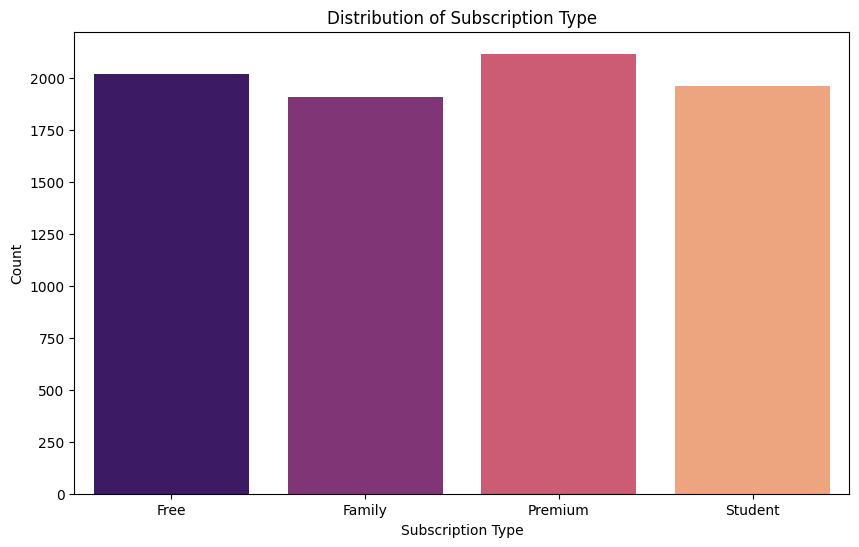

In [39]:
# Distribution of Subscription Type
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='subscription_type', hue='subscription_type', palette='magma', legend=False)
plt.title('Distribution of Subscription Type')
plt.xlabel('Subscription Type')
plt.ylabel('Count')
plt.show()

####Business Insights
Premium subscriptions dominate, while Free users present the largest growth opportunity, with balanced adoption across all plans.

**Strong revenue base**: Premium users are already high.
**Growth lever**: Free users → biggest upgrade opportunity.
**Optimization area**:
Improve Family plan adoption (maybe pricing or bundled value).
Target Student users with retention strategies (they may churn easily after eligibility ends).

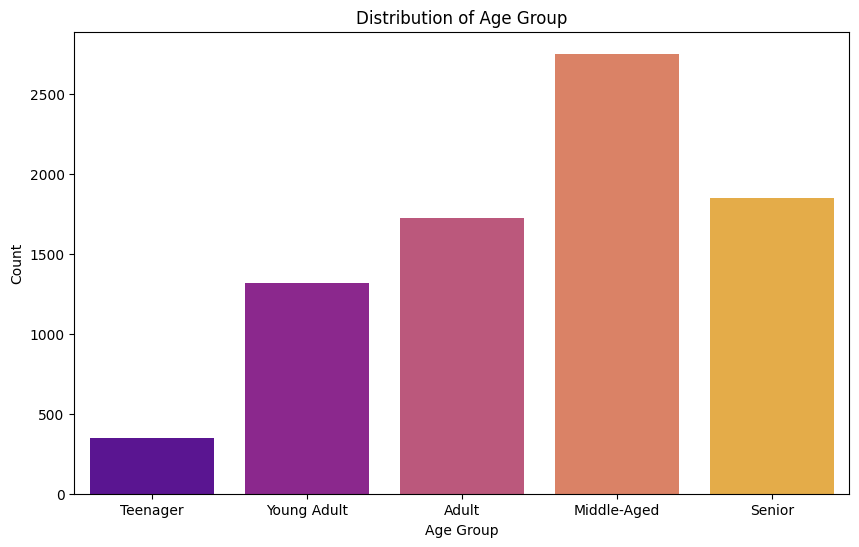

In [40]:
# Distribution of Age Group
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='age_group', hue='age_group', palette='plasma', order=['Teenager', 'Young Adult', 'Adult', 'Middle-Aged', 'Senior'], legend=False)
plt.title('Distribution of Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

#### Business Insights

Middle-aged users form the largest segment, making them the primary
revenue-driving group.
Adults and Seniors contribute a solid secondary base, indicating stable usage across mature age groups.
Teenagers are significantly underrepresented, highlighting a gap in early user acquisition.

### Distribution of Numerical Features

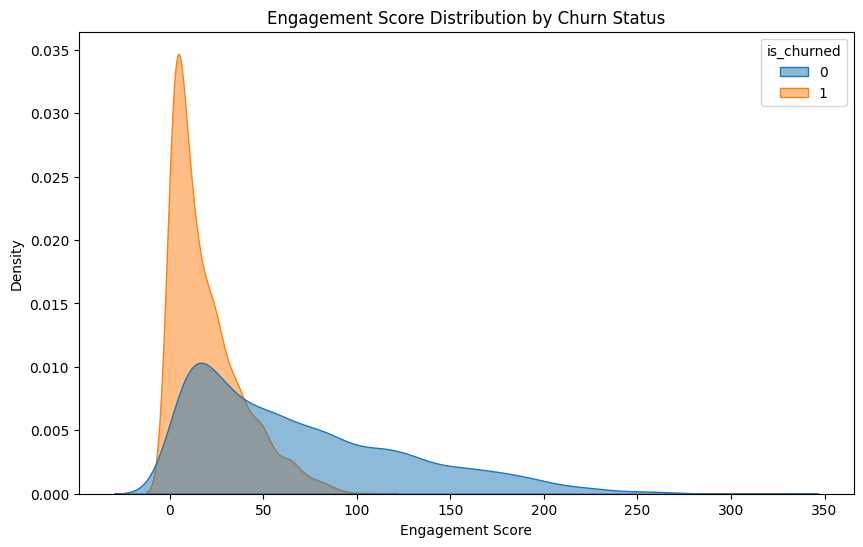

In [56]:
#Engagement Score Distribution by Churn Status
plt.figure(figsize=(10,6))
sns.kdeplot(data=df,x='engagement_score',hue='is_churned',fill=True,common_norm=False, alpha=0.5)
plt.title('Engagement Score Distribution by Churn Status')
plt.xlabel('Engagement Score')
plt.ylabel('Density')
plt.show()

#### Business Insights

The KDE plot shows a strong left-skewed distribution for churned users, indicating that low engagement is a primary driver of churn. Retained users dominate the higher engagement range, suggesting a strong positive relationship between engagement and retention.

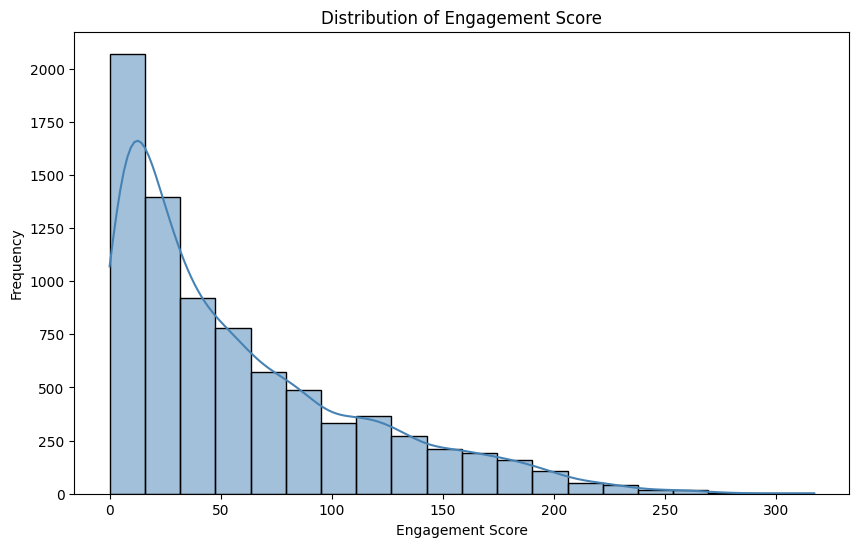

In [42]:
# Distribution of Engagement Score
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='engagement_score', bins=20, kde=True, color='steelblue')
plt.title('Distribution of Engagement Score')
plt.xlabel('Engagement Score')
plt.ylabel('Frequency')
plt.show()

#### Business Insights

Engagement is fairly evenly distributed across users,
 with no extreme concentration in a single range.
 A large portion of users fall in the mid-to-high
  engagement range, indicating consistent platform usage. Very low and very high engagement users are fewer, suggesting most users are moderately active rather than inactive or power users. **However, as observed in later analyses, this engagement does not appear to significantly differentiate between churned and active users.**

## Distribution of Numerical Features

### Violin Plot: Engagement Score Distribution by Churn Status

This plot visualizes the distribution of the 'engagement_score' for both active and churned users. It helps to determine if higher or lower engagement scores are associated with a higher likelihood of churn.

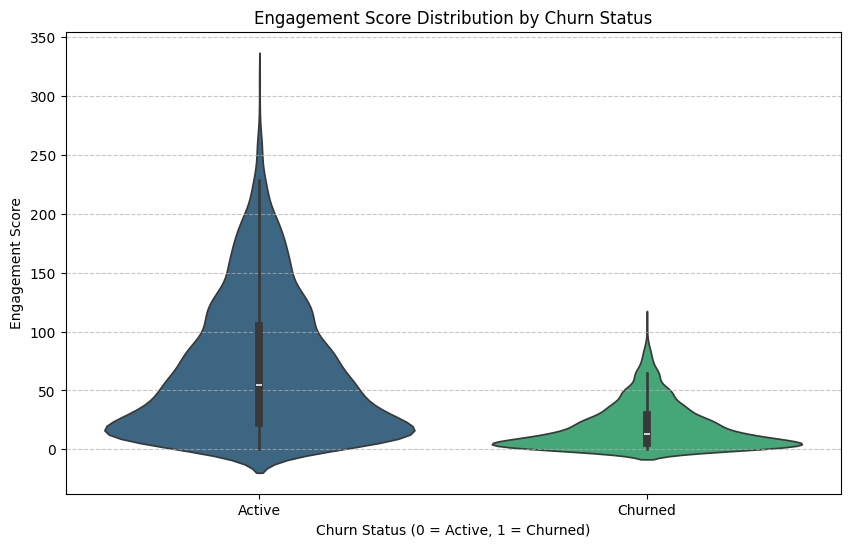

In [58]:
# Engagement Score Distribution by Churn Status
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='is_churned', y='engagement_score', hue='is_churned', palette='viridis', legend=False)
plt.title('Engagement Score Distribution by Churn Status')
plt.xlabel('Churn Status (0 = Active, 1 = Churned)')
plt.ylabel('Engagement Score')
plt.xticks([0, 1], ['Active', 'Churned'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Business Insights

The violin plot reveals a clear shift in engagement distribution between active and churned users, with churned users concentrated at lower engagement levels, reinforcing engagement decline as a key behavioral indicator of churn.


In [44]:
#Bivariate Analysis

### Scatter Plot: Relationship between Listening Time and Engagement Score

This plot will help us understand if there's a direct relationship between how much a user listens and their overall engagement score.

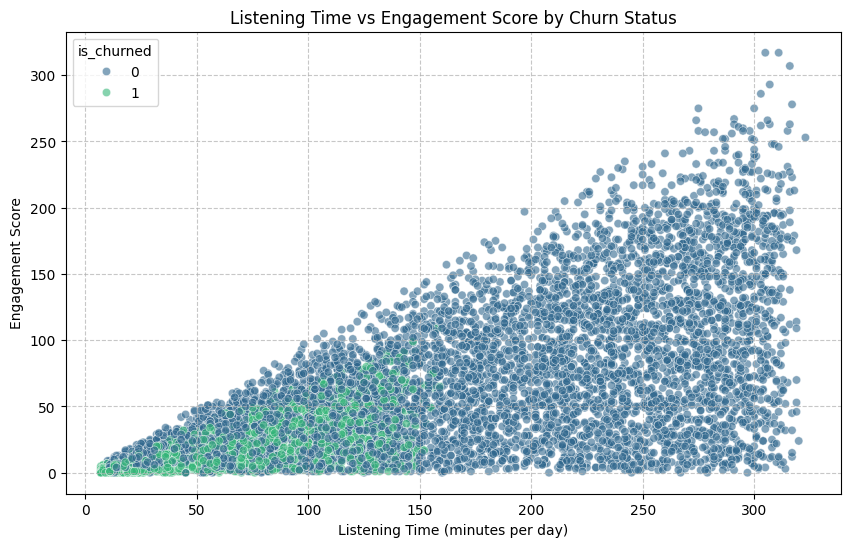

In [59]:
# Listening Time vs. Engagement Score by Churn Status
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='listening_time', y='engagement_score', hue='is_churned', palette='viridis', alpha=0.6)
plt.title('Listening Time vs Engagement Score by Churn Status')
plt.xlabel('Listening Time (minutes per day)')
plt.ylabel('Engagement Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### Business Insights

Users with higher listening activity tend to exhibit higher engagement scores. However, churned users consistently maintain lower engagement levels compared to retained users across listening-time segments.

### Bar Plot: Average Engagement Score by Subscription Type

This bar plot will illustrate how the average engagement score differs across various subscription types.

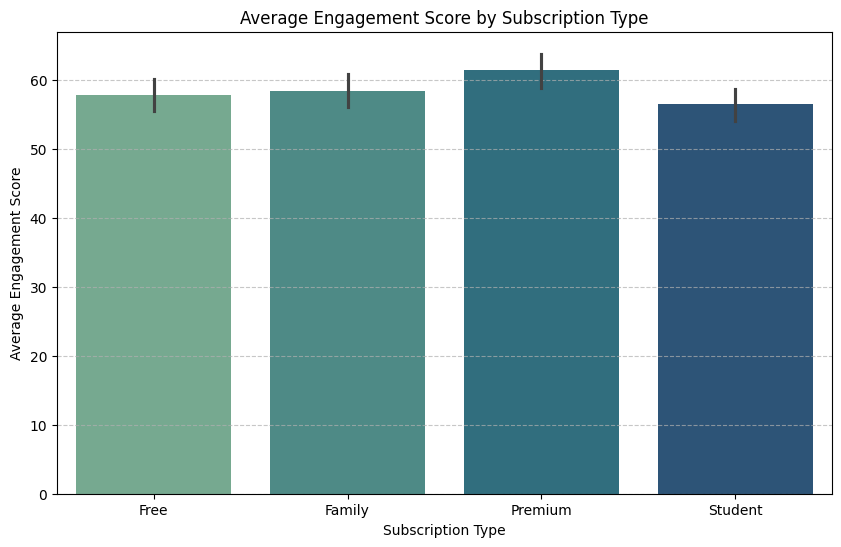

In [46]:
# Average Engagement Score by Subscription Type
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='subscription_type', y='engagement_score', hue='subscription_type', palette='crest', legend=False)
plt.title('Average Engagement Score by Subscription Type')
plt.xlabel('Subscription Type')
plt.ylabel('Average Engagement Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Business Insights

Users with premium-based subscription plans exhibit higher engagement scores compared to free users, suggesting that paid subscribers interact more actively and consistently with the platform.

Free users demonstrate comparatively lower engagement, which may indicate reduced platform involvement and a higher likelihood of churn.

### Correlation Heatmap of Numerical Features

A correlation heatmap provides a visual representation of the correlation coefficients between all pairs of numerical features in the dataset. This helps us quickly identify strong positive or negative relationships between variables.

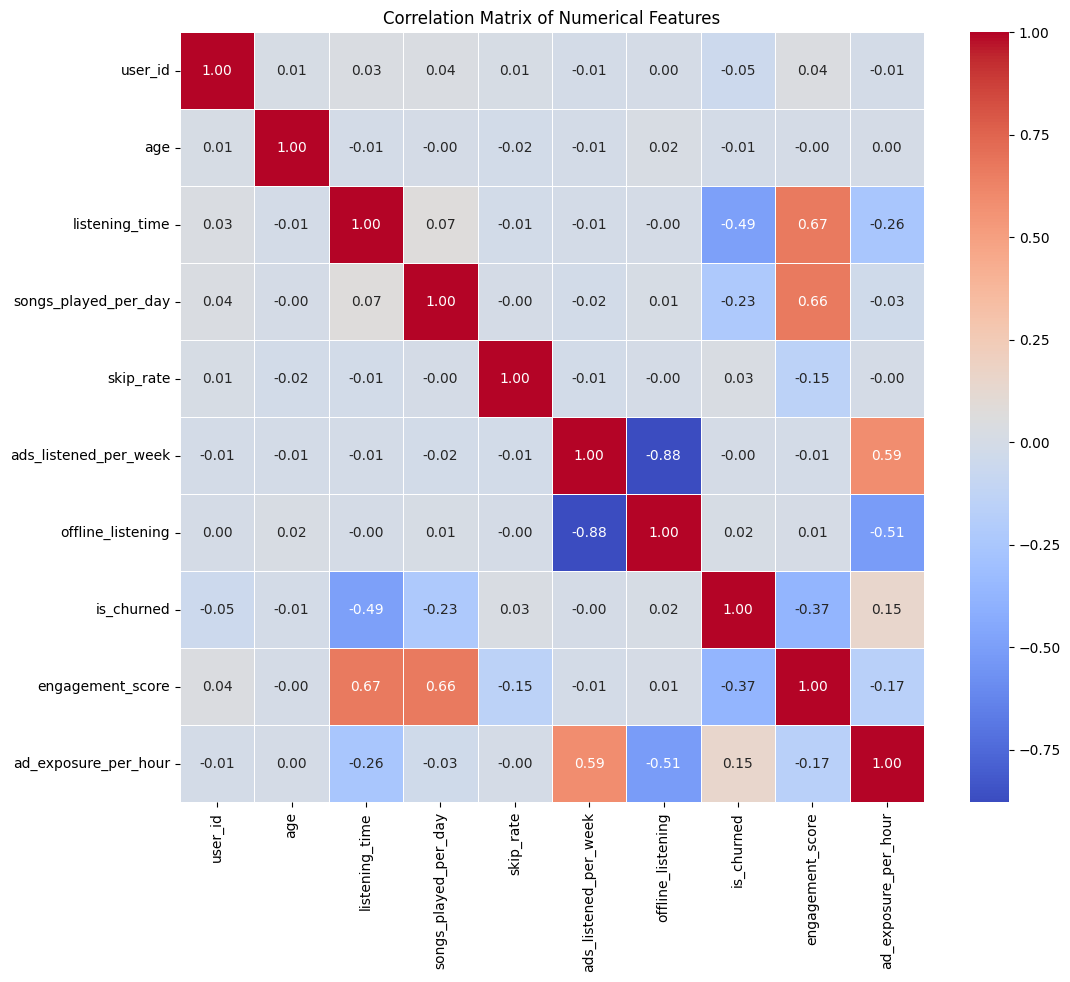

In [47]:
# Correlation Matrix of Numerical Features
plt.figure(figsize=(12, 10))
correlation_matrix = df.select_dtypes(include=['number']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

#### Business Insights

Listening time, songs played per day, and engagement score exhibit strong positive correlations, indicating that highly active users tend to demonstrate stronger overall platform engagement.

In [48]:
#Multivariate Analysis

### Pairplot: Relationships Across Multiple Numerical Features by Churn Status

A pairplot (also known as a scatterplot matrix) visualizes pairwise relationships between multiple numerical variables. By coloring the points based on the 'is_churned' status, we can observe if specific patterns in these relationships are associated with churn.

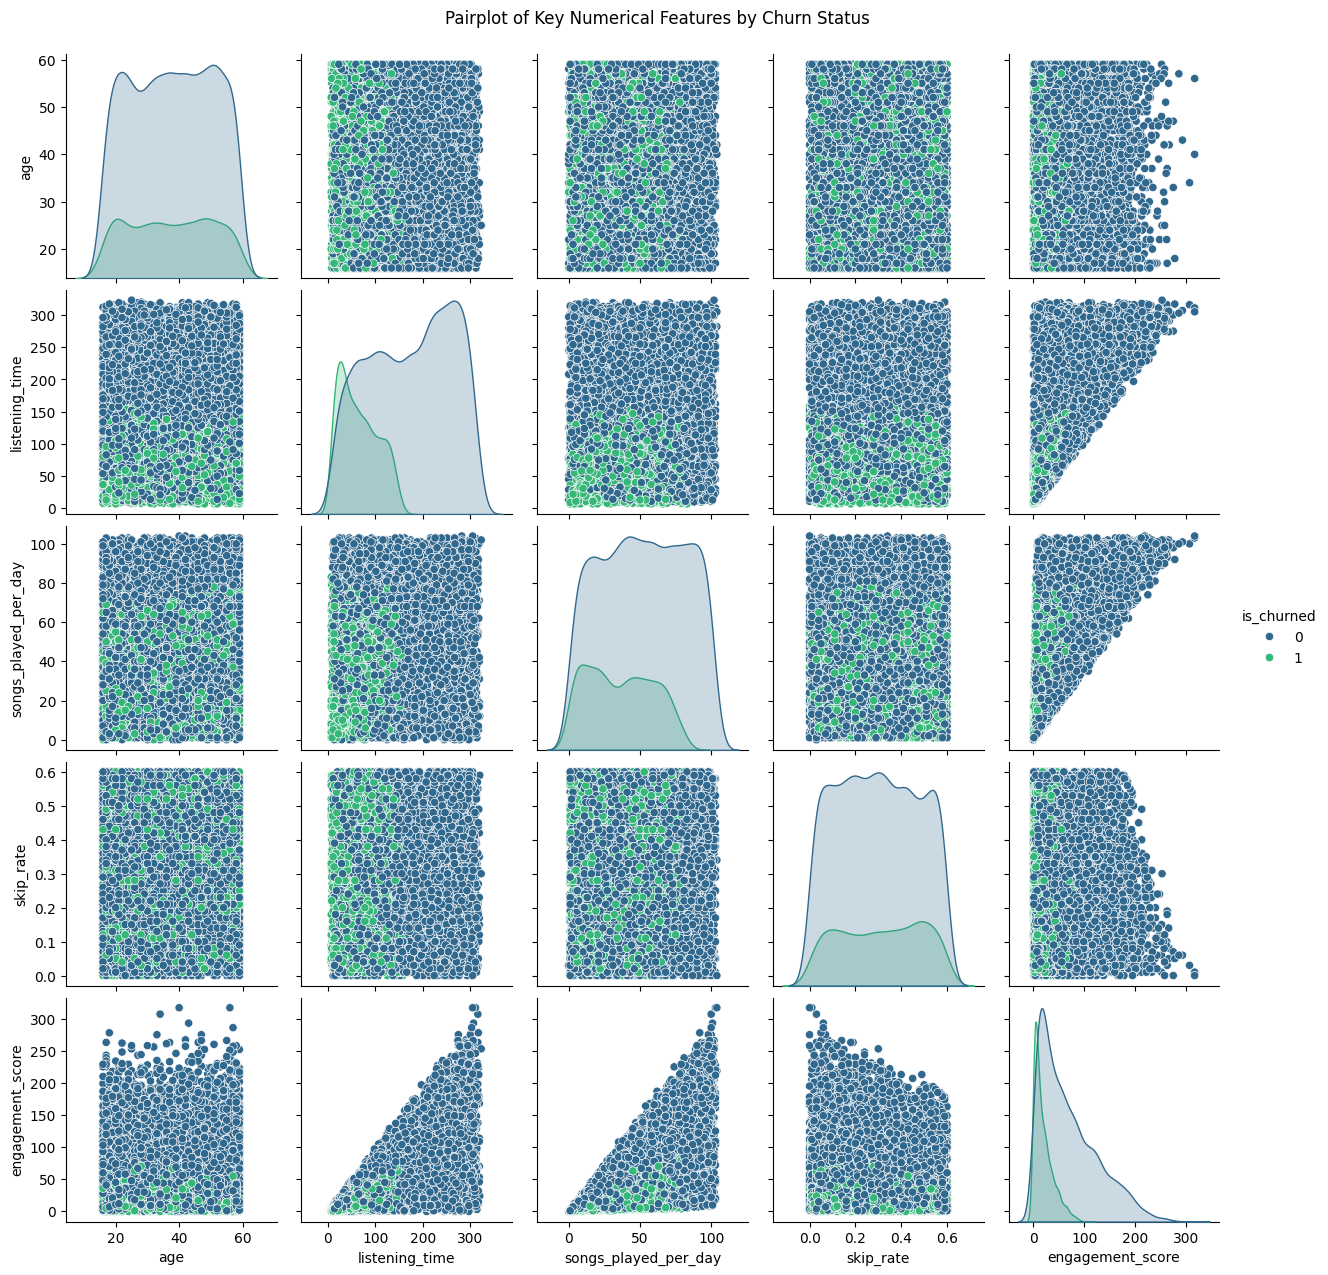

In [49]:
selected_cols = ['age', 'listening_time', 'songs_played_per_day', 'skip_rate', 'engagement_score', 'is_churned']
sns.pairplot(df[selected_cols], hue='is_churned', palette='viridis', diag_kind='kde')
plt.suptitle('Pairplot of Key Numerical Features by Churn Status', y=1.02) # Adjust subtitle position
plt.show()

#### Business Insights

Higher engagement reduces churn
→ Retained users consistently show stronger engagement and listening activity.

Listening Time & Engagement are strongly related
→ Users who spend more time on the platform tend to be more engaged.

Churned users show lower platform activity
→ Churned users are concentrated in lower listening-time and engagement regions.

Songs Played & Listening Time are highly correlated
→ Both features represent overall user activity and platform usage intensity.

Skip rate shows mild churn tendency
→ Users with higher skip behavior exhibit slightly lower engagement patterns.

### Grouped Analysis: Average Engagement Score by Subscription Type and Churn Status

This analysis will group the data by 'subscription_type' and 'is_churned' to calculate the average 'engagement_score'. A bar plot will then effectively visualize these averages, showing how engagement differs across subscription types for both churned and active users.

<Figure size 1200x700 with 0 Axes>

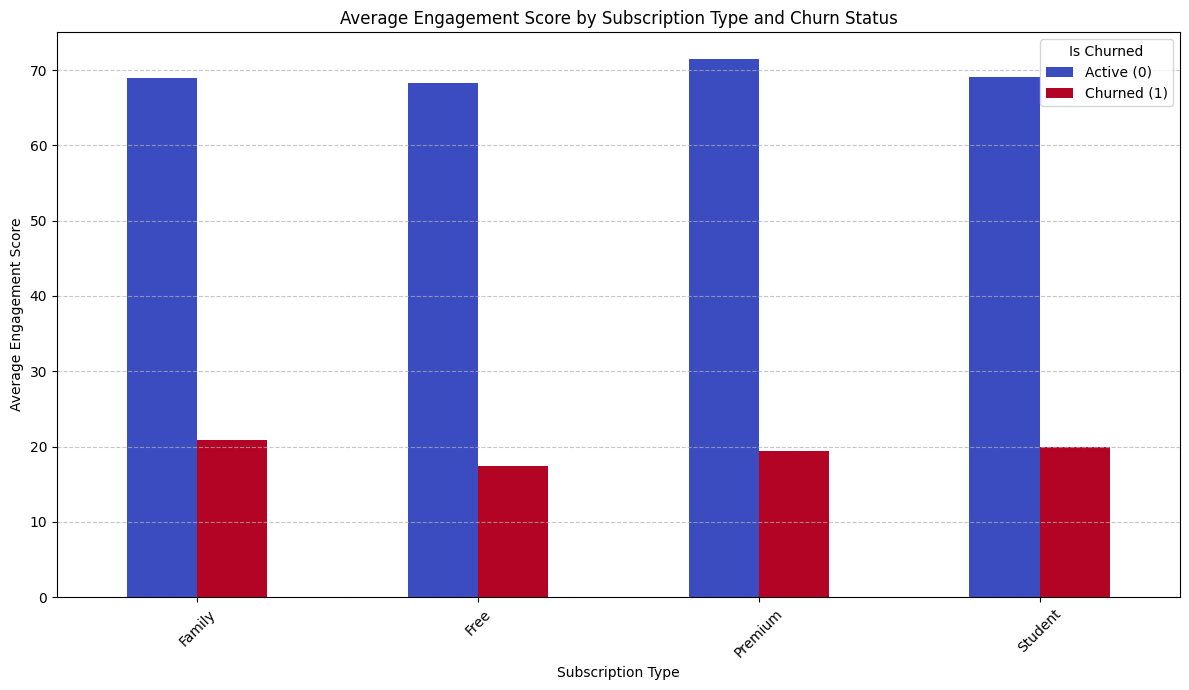

In [50]:
# Average Engagement Score by Subscription Type and Churn Status
avg_engagement_by_sub_churn = df.groupby(['subscription_type', 'is_churned'])['engagement_score'].mean().unstack()

plt.figure(figsize=(12, 7))
avg_engagement_by_sub_churn.plot(kind='bar', figsize=(12, 7), colormap='coolwarm')
plt.title('Average Engagement Score by Subscription Type and Churn Status')
plt.xlabel('Subscription Type')
plt.ylabel('Average Engagement Score')
plt.xticks(rotation=45)
plt.legend(title='Is Churned', labels=['Active (0)', 'Churned (1)']) # Custom labels for legend
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

#### Business Insights

Across all subscription plans, churned users consistently exhibit lower engagement scores compared to active users, indicating that declining engagement is strongly associated with churn regardless of subscription type.

### Pivot Table and Heatmap: Churn Rate by Age Group and Subscription Type

To understand how churn rate varies across different age groups and subscription types, we will create a pivot table. This table will be visualized as a heatmap, allowing us to easily spot demographic segments with higher or lower churn rates.

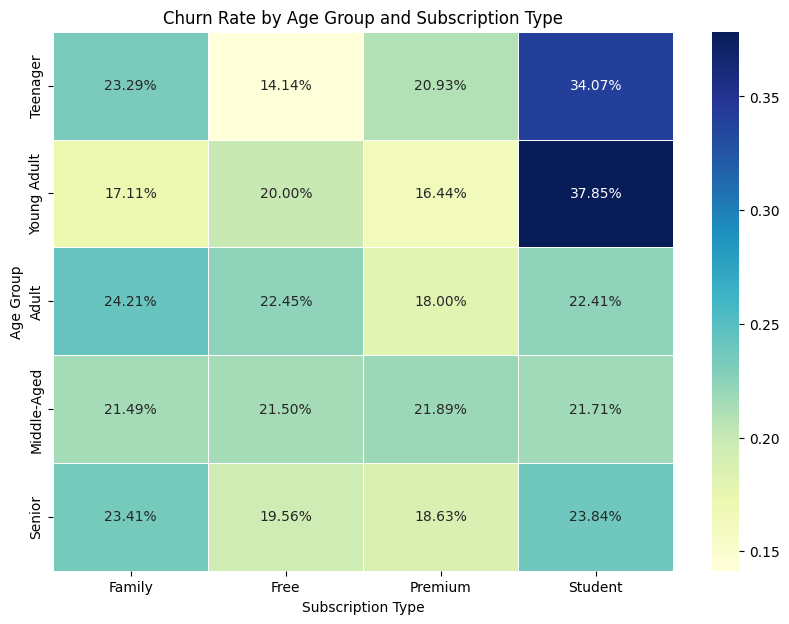

In [51]:
# Churn Rate by Age Group and Subscription Type
churn_rate_pivot = df.pivot_table(values='is_churned', index='age_group', columns='subscription_type', aggfunc='mean', observed=False)

plt.figure(figsize=(10, 7))
sns.heatmap(churn_rate_pivot, annot=True, cmap='YlGnBu', fmt='.2%', linewidths=.5)
plt.title('Churn Rate by Age Group and Subscription Type')
plt.xlabel('Subscription Type')
plt.ylabel('Age Group')
plt.show()

####Business Insights

Churn varies slightly across subscription types
→ Certain subscription plans exhibit comparatively higher churn rates within specific age groups.

Free users show relatively higher churn tendency
→ Users under free subscription plans demonstrate higher churn rates compared to premium-based plans.

Age alone is not the primary churn driver
→ Churn differences across age groups remain relatively moderate compared to engagement-related behaviors.

Premium-based subscriptions show stronger retention
→ Family, Student, and Premium plans generally maintain lower churn rates across most age segments.

Young and middle-aged users contribute significantly to churn volume
→ These groups represent a major portion of platform users and therefore contribute more noticeably to churn patterns.

### Advanced Plot: Engagement Score Distribution by Device Type, Gender, and Churn Status

This `catplot` will display the distribution of 'engagement_score' across 'device_type' and 'gender', further separated by 'is_churned'. This allows for a granular view of how engagement varies across these multiple categorical dimensions, and how that relates to churn.

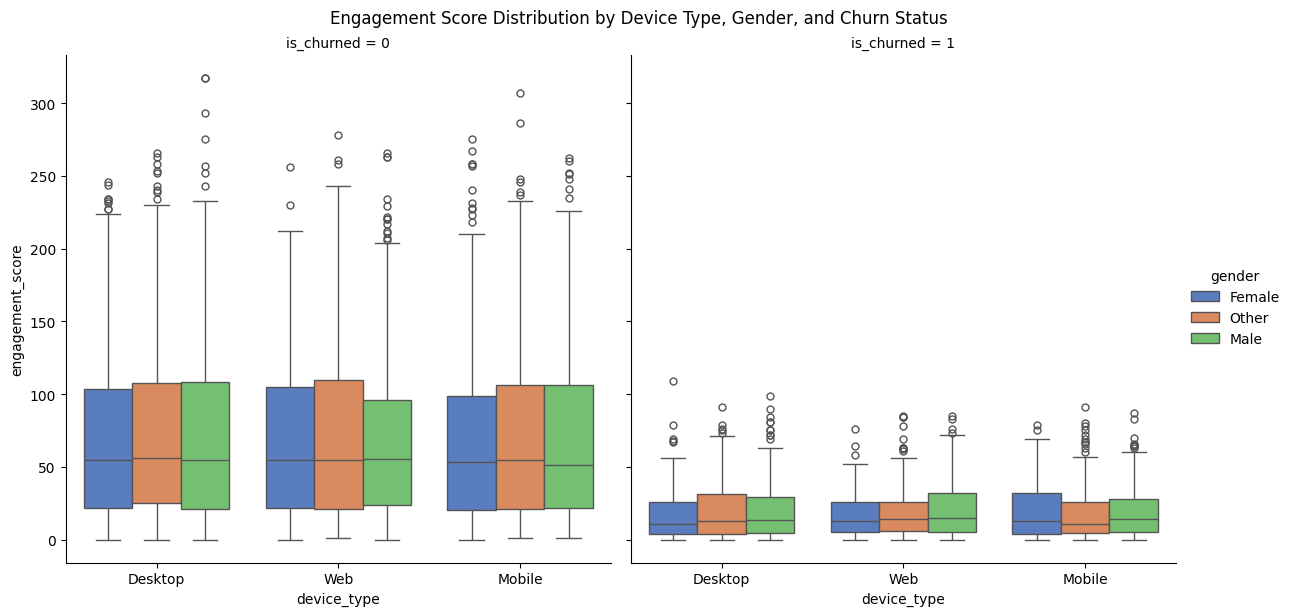

In [52]:
sns.catplot(data=df, x='device_type', y='engagement_score', hue='gender', col='is_churned', kind='box', palette='muted', height=6, aspect=1)
plt.suptitle('Engagement Score Distribution by Device Type, Gender, and Churn Status', y=1.02)
plt.show()

###Business Insights

The boxplot analysis indicates that churned users consistently exhibit lower engagement distributions across device types, while gender-based engagement differences remain relatively minimal.


In [54]:
#Exportind csv file from Python
df.to_csv('final_spotify_churn_data.csv', index=False)
print('DataFrame exported to final_spotify_churn_data.csv')

DataFrame exported to final_spotify_churn_data.csv


PowerBI Link
https://drive.google.com/file/d/1XR0nvtqClzIAJpPiF81LGilgm0U2xYqP/view?usp=sharing

Final Documentation Link

Overall Project Link
https://drive.google.com/drive/folders/1RUaNAGbAHvn2wPvSHeq5iKlxTwgIklpO?usp=sharing

GitHub Link
